#### Machine Learning Teil: Entscheidungsbaum
#### Meine Aufgabe laut Protokoll ist es, einen Entscheidungsbaum aufzustellen und zu bewerten.
#### Random Forest übernimmt mein Teammate separat.
#### Erkenntnisse aus der Vorbereitung:
#### - Die Zielvariable ist stark unbalanciert: nur 3,64% der Fahrer haben einen Schaden gemeldet.
#### - Fehlende Werte sind in dieser OpenML-Version bereits als NaN kodiert (nicht als -1 wie im
####   Original-Kaggle-Datensatz); am stärksten betroffen sind ps_car_03_cat (~69%) und
####   ps_car_05_cat (~45%).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
)

##### 1. Daten laden

In [2]:
print("Lade Porto Seguro Datensatz...")
dataset = fetch_openml(data_id=42742, as_frame=True)
X = dataset.data
y = dataset.target.astype(int)

Lade Porto Seguro Datensatz...


#### Meine eigene kurze EDA (Explorative Datenanalyse) - Teil 1 & 2
#### Gemäß unserer Gruppenabmachung ("EDA alleine + gemeinsamer Austausch") habe ich mir
#### die Verteilung der Zielvariable sowie die Korrelationen der numerischen Features
#### visualisiert, bevor ich mit dem Modell-Training starte.
##### 1. Visualisierung des starken Ungleichgewichts (Imbalance)

C:\Users\hp\AppData\Local\Temp\ipykernel_8012\3300911202.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["0 (Sicherer Fahrer)", "1 (Riskanter Fahrer)"])


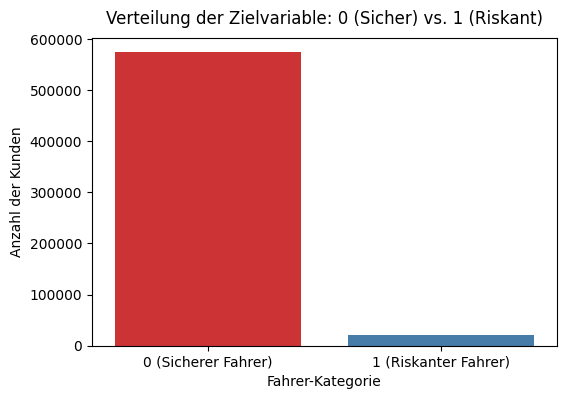

Anteil riskanter Fahrer: 3.64%


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=y, order=[0, 1], hue=y, palette="Set1", legend=False, ax=ax)
ax.set_title("Verteilung der Zielvariable: 0 (Sicher) vs. 1 (Riskant)", fontsize=12, pad=10)
ax.set_xlabel("Fahrer-Kategorie")
ax.set_ylabel("Anzahl der Kunden")
ax.set_xticklabels(["0 (Sicherer Fahrer)", "1 (Riskanter Fahrer)"])
plt.show()

anteil_riskant = (y == 1).mean() * 100
print(f"Anteil riskanter Fahrer: {anteil_riskant:.2f}%")

##### **Erkenntnis:** Das Diagramm zeigt extrem deutlich, dass wir fast nur Klasse 0 haben
##### (nur ca. 3,6% Klasse 1). Ohne ein `class_weight="balanced"` würde unser Modell die
##### Unfälle einfach ignorieren, da es auch ohne jede Erkennung von Klasse 1 schon zu über 96%
##### "richtig" läge.
#
##### 2. Korrelations-Heatmap der kontinuierlichen Variablen
##### Wir filtern die kategorischen (_cat) und binären (_bin) Spalten heraus.

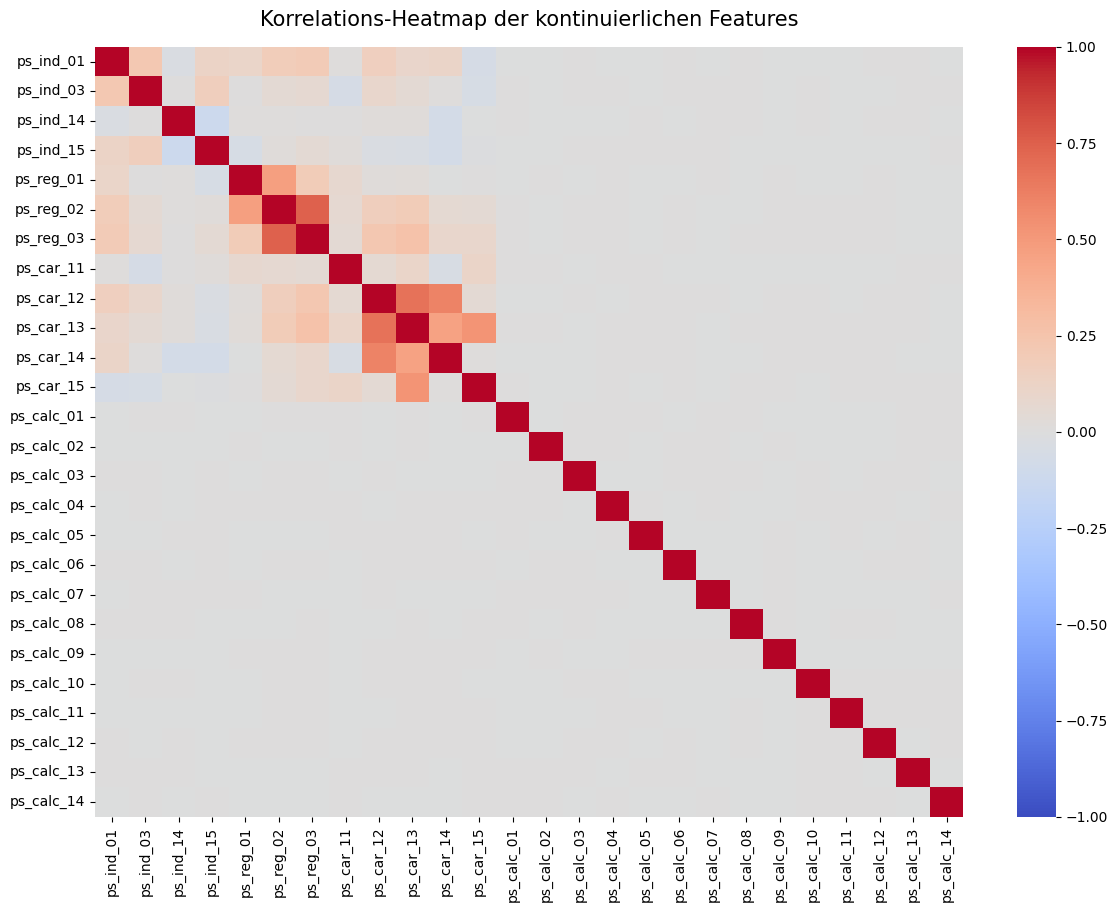

Stärkste Korrelationspaare (nach Betrag sortiert):
ps_reg_03  ps_reg_02    0.742668
ps_car_13  ps_car_12    0.672014
ps_car_14  ps_car_12    0.603361
ps_car_13  ps_car_15    0.529519
ps_reg_01  ps_reg_02    0.471027
ps_car_14  ps_car_13    0.459047
ps_car_13  ps_reg_03    0.264800
ps_reg_03  ps_car_12    0.228926
ps_ind_03  ps_ind_01    0.223408
ps_ind_01  ps_reg_03    0.202096
dtype: float64


In [6]:
num_cols_eda = [col for col in X.columns if not col.endswith('_cat') and not col.endswith('_bin')]
corr_matrix = X[num_cols_eda].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, vmin=-1, vmax=1, ax=ax)
ax.set_title("Korrelations-Heatmap der kontinuierlichen Features", fontsize=15, pad=15)
plt.show()

# Stärkste Korrelationspaare numerisch auflisten (statt nur visuell zu schätzen)
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]  # Diagonale (Korrelation mit sich selbst) rausfiltern
top_pairs = corr_pairs.sort_values(ascending=False).drop_duplicates().head(10)
print("Stärkste Korrelationspaare (nach Betrag sortiert):")
print(top_pairs)

##### **Erkenntnis:** Die numerische Auswertung bestätigt den optischen Eindruck der Heatmap:
##### Die meisten Feature-Paare korrelieren nur schwach. Es gibt aber ein paar auffällige
##### Ausnahmen mit spürbar höherer Korrelation (siehe Tabelle oben) - das sind Kandidaten für
##### mögliche Redundanz. Für baumbasierte Modelle wie unseren Decision Tree ist das weniger
##### kritisch als z.B. für die Logistic Regression meines Teammates, da Bäume robuster
##### gegenüber korrelierten Features sind.

##### 2. Fehlende Werte checken
##### mein teammate hat in seiner EDA direkt mit df.isnull() gearbeitet (nicht mit -1) - und das deckt
##### sich mit unserem eigenen Check: In dieser OpenML-Version (ID 42742) sind fehlende Werte
##### bereits als echtes NaN kodiert, nicht als -1 wie im Original-Kaggle-Datensatz. Wir arbeiten
##### deshalb direkt mit NaN weiter.


In [7]:
missing_counts = X.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
print(missing_counts)

ps_car_03_cat    411231
ps_car_05_cat    266551
ps_reg_03        107772
ps_car_14         42620
ps_car_07_cat     11489
ps_ind_05_cat      5809
ps_car_09_cat       569
ps_ind_02_cat       216
ps_car_01_cat       107
ps_ind_04_cat        83
ps_car_02_cat         5
ps_car_11             5
ps_car_12             1
dtype: int64


##### 3. Train-Test-Split
##### WICHTIG: stratify=y sorgt dafür, dass wir in Train und Test genau die 3,64% Unfälle behalten!

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Daten wurden erfolgreich in 80% Training und 20% Test aufgeteilt.")

Daten wurden erfolgreich in 80% Training und 20% Test aufgeteilt.


##### Datenvorbereitung (Scikit-Learn Pipeline)
##### Baumbasierte Modelle brauchen keine Skalierung. Bei den kategorischen Spalten (_cat) mit
##### häufigstem Wert auffüllen + One-Hot-Encoding, bei den restlichen (Zahlen) mit dem Median.


In [9]:
cat_cols = [col for col in X_train.columns if col.endswith('_cat')]
num_cols = [col for col in X_train.columns if col not in cat_cols]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False)
)

num_pipeline = make_pipeline(
    SimpleImputer(strategy="median")
)

preprocessor = make_column_transformer(
    (cat_pipeline, cat_cols),
    (num_pipeline, num_cols),
).set_output(transform="pandas")

##### Hyperparameter-Suche (Welche Tiefe ist die beste?)
##### Wenn der Baum zu tief wird, lernt er die Trainingsdaten auswendig (Overfitting). Wir nutzen
##### GridSearchCV mit 5-facher Cross-Validation, nur auf den Trainingsdaten (der Testdatensatz
##### bleibt bis zur finalen Bewertung unangetastet - kein Data Leakage).
#
##### Hinweis: class_weight="balanced" ist zwingend nötig wegen unserer imbalanced Data!


In [10]:
param_grid = {"decisiontreeclassifier__max_depth": [3, 5, 7, 10, 15]}

tree_grid = GridSearchCV(
    make_pipeline(preprocessor, DecisionTreeClassifier(class_weight="balanced", random_state=42)),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)
tree_grid.fit(X_train, y_train)

print("Beste Tiefe laut Cross-Validation:", tree_grid.best_params_)
print("Bester CV-AUC:", round(tree_grid.best_score_, 4))

cv_results = pd.DataFrame(tree_grid.cv_results_)[
    ["param_decisiontreeclassifier__max_depth", "mean_test_score"]
]
print(cv_results)

Beste Tiefe laut Cross-Validation: {'decisiontreeclassifier__max_depth': 7}
Bester CV-AUC: 0.6018
   param_decisiontreeclassifier__max_depth  mean_test_score
0                                        3         0.587547
1                                        5         0.600745
2                                        7         0.601765
3                                       10         0.579586
4                                       15         0.535265


##### Finaler Entscheidungsbaum

In [11]:
final_tree = tree_grid.best_estimator_

##### Auswertung der Metriken
##### Precision, Recall, F1 und ROC-AUC statt reiner Accuracy, da unsere Daten stark unbalanciert
##### sind (ein Modell, das immer "kein Schaden" vorhersagt, wäre zu 96,4% "richtig", aber nutzlos).


In [12]:
y_pred = final_tree.predict(X_test)
proba_tree = final_tree.predict_proba(X_test)[:, 1]

metriken = {
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, proba_tree)
}

df_metriken = pd.DataFrame([metriken], index=["Entscheidungsbaum"])
display(df_metriken.round(4))

,Precision,Recall,F1-Score,ROC-AUC
Entscheidungsbaum,0.0502,0.5248,0.0917,0.6031


##### Visualisierung 1: ROC-Kurve

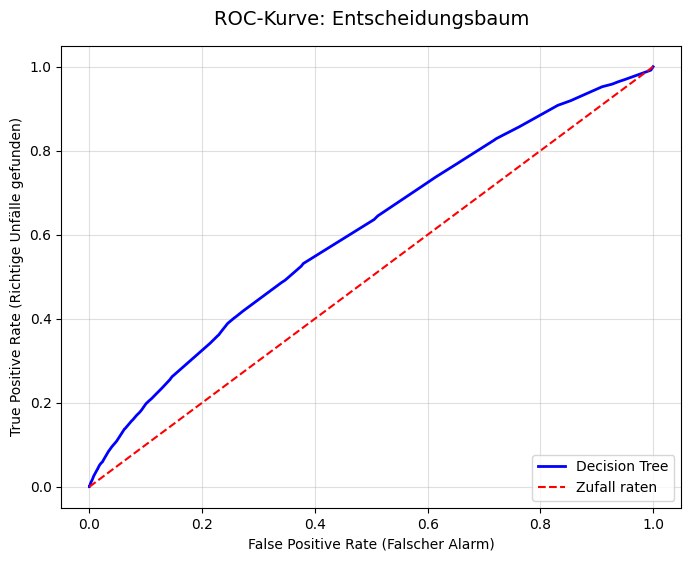

In [13]:
fpr, tpr, _ = roc_curve(y_test, proba_tree)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, label="Decision Tree", color="blue", linewidth=2)
ax.plot([0, 1], [0, 1], label="Zufall raten", color="red", linestyle="--")
ax.set_title("ROC-Kurve: Entscheidungsbaum", fontsize=14, pad=15)
ax.set_xlabel("False Positive Rate (Falscher Alarm)")
ax.set_ylabel("True Positive Rate (Richtige Unfälle gefunden)")
ax.legend(loc="lower right")
ax.grid(alpha=0.4)
plt.show()

##### Visualisierung 2: Confusion Matrix
##### Zeigt anschaulich, wie sich Precision und Recall zusammensetzen.

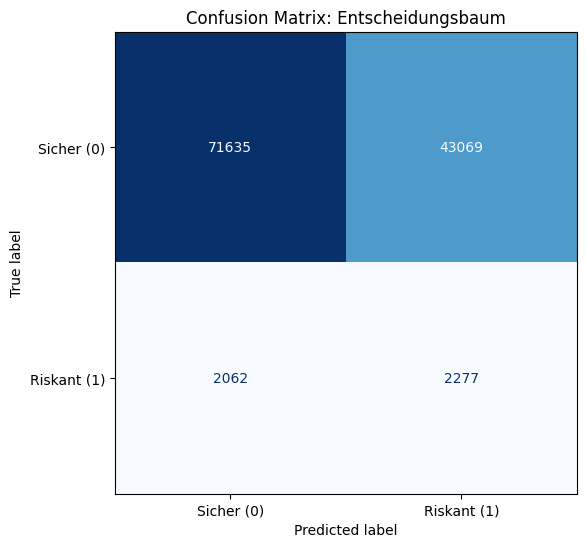

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(
    final_tree, X_test, y_test,
    display_labels=["Sicher (0)", "Riskant (1)"],
    cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("Confusion Matrix: Entscheidungsbaum")
plt.show()

##### Visualisierung 3: Precision-Recall-Kurve
##### Bei stark unbalancierten Daten (3,64% Positivklasse) oft aussagekräftiger als die ROC-Kurve.

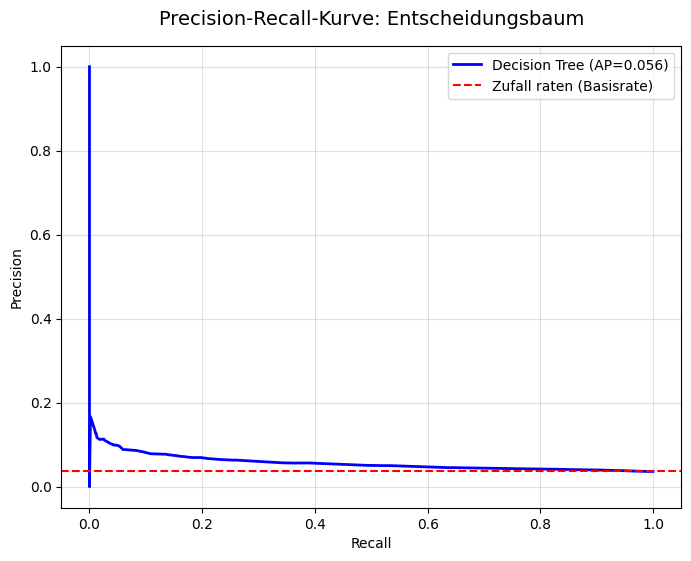

In [15]:
prec, rec, _ = precision_recall_curve(y_test, proba_tree)
ap = average_precision_score(y_test, proba_tree)
baseline = y_test.mean()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec, prec, label=f"Decision Tree (AP={ap:.3f})", color="blue", linewidth=2)
ax.axhline(baseline, label="Zufall raten (Basisrate)", color="red", linestyle="--")
ax.set_title("Precision-Recall-Kurve: Entscheidungsbaum", fontsize=14, pad=15)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="upper right")
ax.grid(alpha=0.4)
plt.show()

##### Visualisierung 4: Feature Importances
##### Zeigt, welche Merkmale der Baum als am wichtigsten einstuft. Guter Querbezug zur
##### Korrelations-Heatmap aus meiner eigenen EDA und aus Amines EDA.

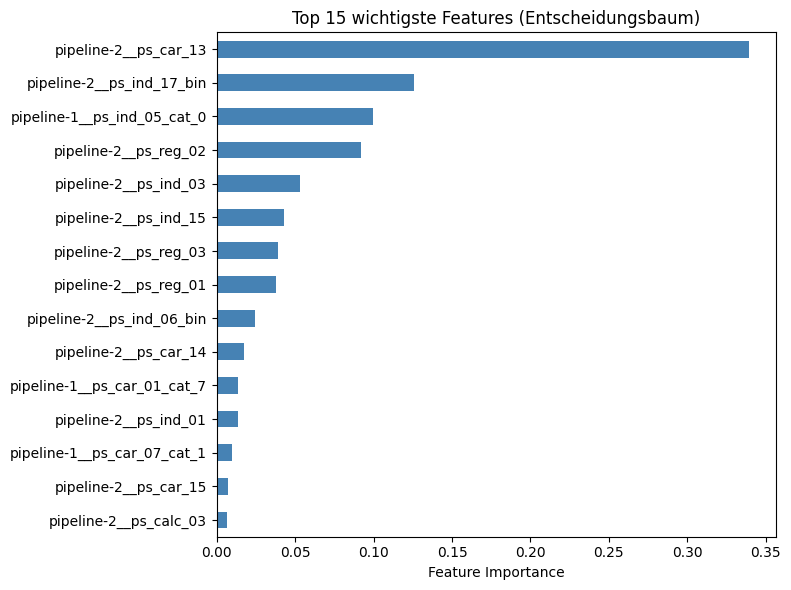

In [16]:
feature_names = final_tree.named_steps["columntransformer"].get_feature_names_out()
importances = final_tree.named_steps["decisiontreeclassifier"].feature_importances_

top_features = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_features.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 wichtigste Features (Entscheidungsbaum)")
ax.set_xlabel("Feature Importance")
plt.tight_layout()
plt.show()

##### Meine eigene kurze EDA - Teil 3: Zusammenhang zwischen wichtigstem Feature und Zielvariable
##### Um die EDA direkt mit meinem Modell zu verknüpfen, schaue ich mir den Zusammenhang zwischen
##### dem laut Decision Tree wichtigsten NUMERISCHEN Feature (aus `feature_importances_`, siehe
##### Visualisierung 4 oben) und der tatsächlichen Schadensrate an. Diese Zelle steht bewusst NACH
##### dem Training, da sie auf den trainierten Baum zugreift - kategorische Features werden hier
##### ausgeschlossen, da sie durch One-Hot-Encoding aufgesplittet wurden und sich nicht so direkt
##### in Bins darstellen lassen wie numerische Werte.

##### Automatisch das wichtigste NICHT-kategorische Feature auswählen (numerische Spalten werden
##### beim Preprocessing nicht one-hot-encodet, ihr Name bleibt bis auf den Pipeline-Präfix erhalten)

Automatisch gewähltes wichtigstes numerisches Feature: ps_car_13


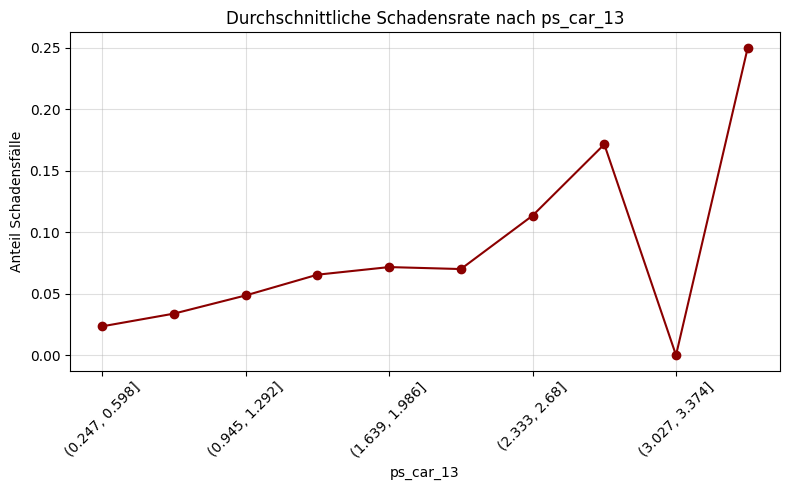

In [17]:
numeric_top_features = top_features[~top_features.index.str.contains("_cat")]
top_feature_full_name = numeric_top_features.index[0]  # höchste Importance zuerst
top_feature = top_feature_full_name.split("__")[-1]

print("Automatisch gewähltes wichtigstes numerisches Feature:", top_feature)

df_plot = X_train.copy()
df_plot["target"] = y_train.values

mean_target_by_feature = df_plot.groupby(pd.cut(df_plot[top_feature], bins=10))["target"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
mean_target_by_feature.plot(marker="o", ax=ax, color="darkred")
ax.set_title(f"Durchschnittliche Schadensrate nach {top_feature}")
ax.set_xlabel(top_feature)
ax.set_ylabel("Anteil Schadensfälle")
ax.grid(alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### **Erkenntnis:** Dieser Plot zeigt, ob und wie stark die Schadensrate mit dem wichtigsten
##### Feature meines Modells zusammenhängt - das ist der direkte Querbezug zwischen EDA und
##### Machine-Learning-Teil, den die Aufgabenstellung explizit fordert.

##### Visualisierung 5: Der Baum selbst
##### Zur besseren Interpretierbarkeit zeigen wir die ersten zwei Ebenen des finalen Baums.

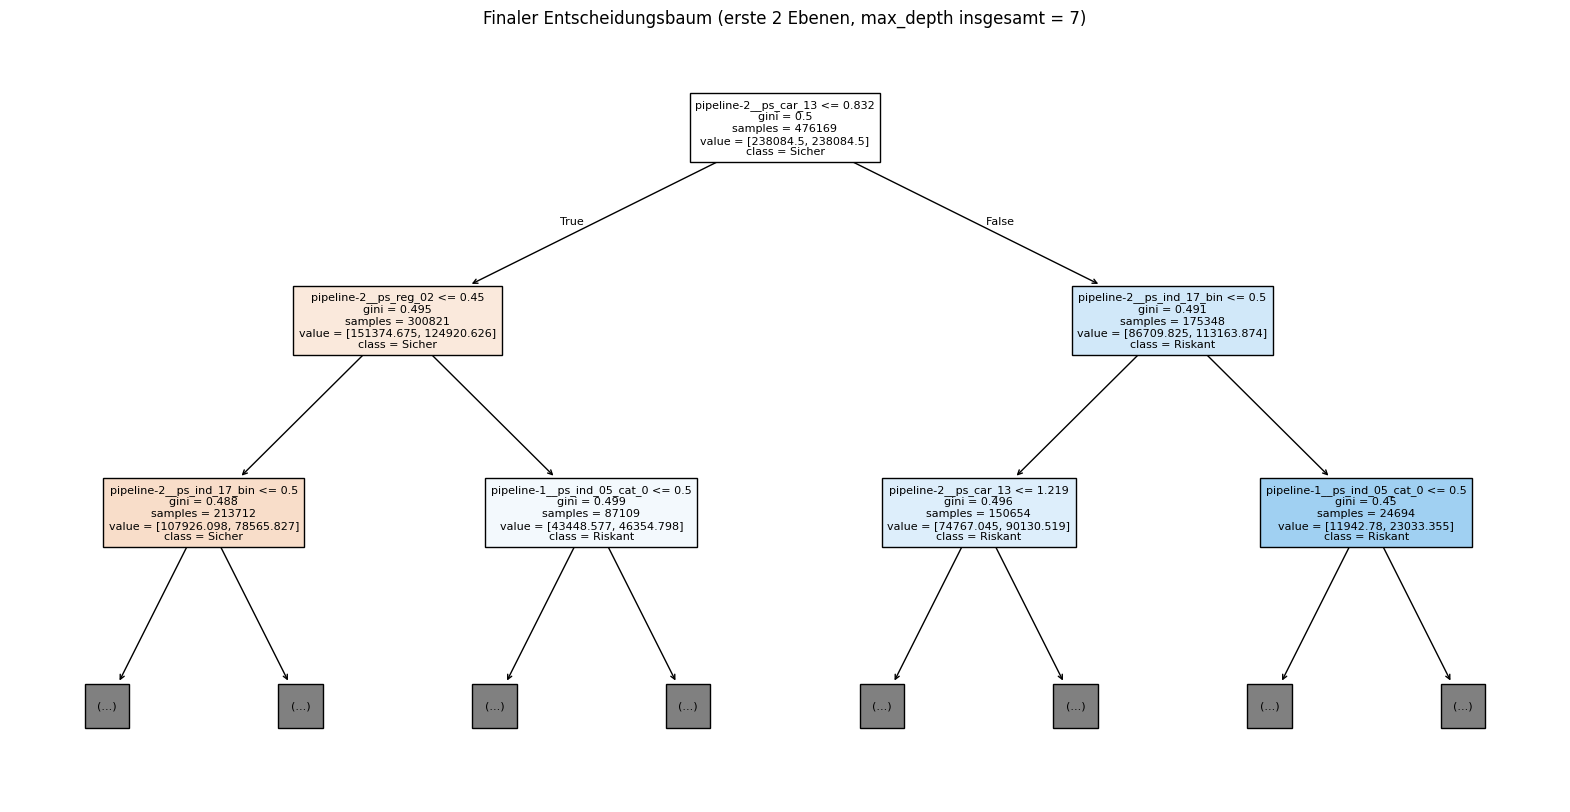

In [18]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    final_tree.named_steps["decisiontreeclassifier"],
    max_depth=2,  # nur obere Ebenen, sonst unlesbar
    feature_names=feature_names,
    class_names=["Sicher", "Riskant"],
    filled=True,
    fontsize=8,
    ax=ax
)
ax.set_title(f"Finaler Entscheidungsbaum (erste 2 Ebenen, max_depth insgesamt = "
             f"{tree_grid.best_params_['decisiontreeclassifier__max_depth']})")
plt.show()

##### Visualisierung 6: Overfitting-Check (Train- vs. CV-Test-AUC nach Tiefe)
##### Zeigt, ob und ab welcher Tiefe der Baum die Trainingsdaten auswendig lernt statt zu
##### generalisieren - liefert die Begründung dafür, warum wir max_depth begrenzt haben.


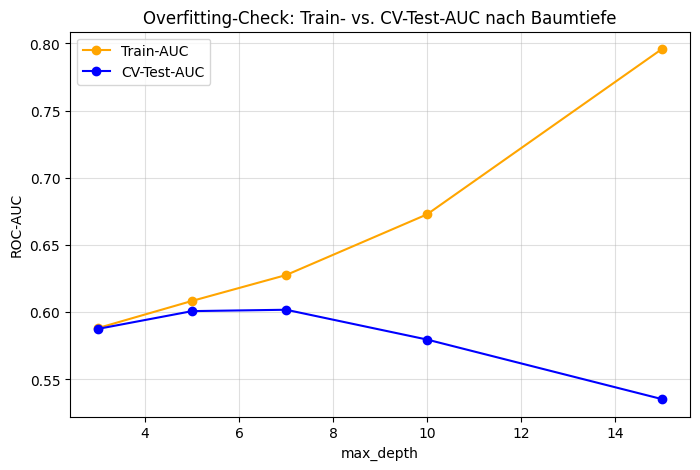

In [19]:
train_aucs = []
for tiefe in param_grid["decisiontreeclassifier__max_depth"]:
    m = make_pipeline(
        preprocessor,
        DecisionTreeClassifier(max_depth=tiefe, class_weight="balanced", random_state=42)
    )
    m.fit(X_train, y_train)
    proba_train = m.predict_proba(X_train)[:, 1]
    train_aucs.append(roc_auc_score(y_train, proba_train))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cv_results["param_decisiontreeclassifier__max_depth"], train_aucs,
        marker="o", label="Train-AUC", color="orange")
ax.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_test_score"],
        marker="o", label="CV-Test-AUC", color="blue")
ax.set_xlabel("max_depth")
ax.set_ylabel("ROC-AUC")
ax.set_title("Overfitting-Check: Train- vs. CV-Test-AUC nach Baumtiefe")
ax.legend()
ax.grid(alpha=0.4)
plt.show()